# 04 · Similarity Search Demo

Use the same **global data selection** as notebook 03, then run embedding-based image retrieval.
Given a query image, return the most similar objects by **cosine similarity** in embedding space.

**Sections:**
1. Global filter configuration (same style as 03)
2. Build searchable dataset + embedding bank
3. Similarity search functions
4. Example plot: original image + nearest objects


In [10]:
import os, sys, glob
import numpy as np
import h5py
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from omegaconf import OmegaConf
from tqdm import tqdm
import matplotlib.pyplot as plt

PROJECT_ROOT = '/u/yacheng/projects/ssl_outthere'
sys.path.insert(0, PROJECT_ROOT)
from dinov2.eval.setup import build_model_for_eval
from encoder_image.astrodino.train.data.augmentations import ToRGB

DEG_TO_PIXEL = 3600 * 1000 / 30   # 120000
MORPH_NAMES  = {0: 'Spheroid', 1: 'Disk-dom.', 2: 'Irregular', 3: 'Bulge-dom.'}
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda:0


## 1 · Global Data Selection (same as 03)
All embeddings and retrieval results use the same filtered subset. Modify here and re-run.


In [11]:
MODEL_CONFIG  = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb/config.yaml'
MODEL_WEIGHTS = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb/eval/training_149999/teacher_checkpoint.pth'
MODEL_CONFIG  = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_bs256/config.yaml'
MODEL_WEIGHTS = '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_bs256/eval/training_99999/teacher_checkpoint.pth'
DATA_ROOT     = '/u/yacheng/projects/ssl_outthere/images/jwst/f150w'

# ── FILTER OPTIONS (same style as 03) ──────────────────────────────────────
REFF_MIN_PIX       = 2.3    # min effective radius [pixels]; None = no filter
REFF_MAX_PIX       = 64     # max effective radius [pixels]; None = no filter
DELTA_THRESHOLD    = 0.5    # max delta (morph confidence);  None = no filter
AR_ERR_THRESH      = 0.05   # max axis_ratio_err/ar;         None = no filter
RE_REL_ERR_THRESH  = 0.05   # max radius_sersic_err/rs;      None = no filter
EXCLUDE_IRREGULAR  = True   # True = drop morph class 2
# ────────────────────────────────────────────────────────────────────────────

N_SAMPLES   = -1  # -1 = use all
BATCH_SIZE  = 64
SEED        = 42
rng = np.random.default_rng(SEED)

print(f'Filters: reff∈[{REFF_MIN_PIX},{REFF_MAX_PIX}] px  delta<{DELTA_THRESHOLD}  exclude_irr={EXCLUDE_IRREGULAR}')


Filters: reff∈[2.3,64] px  delta<0.5  exclude_irr=True


## 2 · Dataset, Model & Embedding Bank


In [12]:
class SearchDataset(Dataset):
    """Filtered dataset for similarity search.
    __getitem__ returns (model_input_tensor, global_index).
    """
    def __init__(self, root, crop_size,
                 reff_min, reff_max, delta_threshold,
                 ar_err_thresh, re_rel_err_thresh,
                 max_samples, exclude_irregular=False, seed=42):
        self.to_rgb = ToRGB()
        self.crop = transforms.CenterCrop(crop_size)
        self._rng = np.random.default_rng(seed)

        self._files = []
        for fp in sorted(glob.glob(os.path.join(root, '*.h5'))):
            f = h5py.File(fp, 'r')
            if all(k in f for k in ['image', 'radius_sersic', 'axis_ratio', 'morph_flag_f150w']):
                self._files.append(f)
            else:
                f.close()
        print(f'Loaded {len(self._files)} files with all fields')

        self._idx = []  # (fi, li, log10_re, ar, morph)
        for fi, f in enumerate(tqdm(self._files, desc='Indexing')):
            rs = f['radius_sersic'][:]
            ar = f['axis_ratio'][:]
            morph = f['morph_flag_f150w'][:]
            delta = f['delta_f150w'][:] if 'delta_f150w' in f else np.full(len(rs), np.nan)
            rs_err = f['radius_sersic_err'][:] if 'radius_sersic_err' in f else None
            ar_err = f['axis_ratio_err'][:] if 'axis_ratio_err' in f else None

            re_pix = rs * DEG_TO_PIXEL
            vmask = (np.isfinite(rs) & (rs > 0) &
                     np.isfinite(ar) & (ar > 0.01) & (ar < 0.99) &
                     np.isfinite(morph) & np.isfinite(delta))

            if delta_threshold is not None:
                vmask &= delta < delta_threshold
            if reff_min is not None:
                vmask &= np.isfinite(re_pix) & (re_pix >= reff_min)
            if reff_max is not None:
                vmask &= np.isfinite(re_pix) & (re_pix <= reff_max)
            if ar_err is not None and ar_err_thresh is not None:
                vmask &= np.isfinite(ar_err) & np.isfinite(ar) & (ar > 0) & ((ar_err / ar) <= ar_err_thresh)
            if rs_err is not None and re_rel_err_thresh is not None:
                vmask &= np.isfinite(rs_err) & np.isfinite(rs) & (rs > 0) & ((rs_err / rs) <= re_rel_err_thresh)
            if exclude_irregular:
                vmask &= (morph != 2)

            for li in np.where(vmask)[0]:
                log_r = np.log10(float(rs[li]) * DEG_TO_PIXEL)
                self._idx.append((fi, li, log_r, float(ar[li]), int(morph[li])))

        print(f'Valid samples: {len(self._idx)}' + (' (Irregular excluded)' if exclude_irregular else ''))
        if max_samples > 0 and max_samples < len(self._idx):
            chosen = self._rng.choice(len(self._idx), size=max_samples, replace=False)
            self._idx = [self._idx[i] for i in chosen]
            print(f'Subsampled to {len(self._idx)}')

    def __len__(self):
        return len(self._idx)

    def __getitem__(self, i):
        fi, li, _, _, _ = self._idx[i]
        img = self._files[fi]['image'][li].astype('float32')
        img3 = np.repeat(img[np.newaxis], 3, axis=0)
        t = self.crop(torch.from_numpy(img3))
        t = torch.from_numpy(self.to_rgb(t.numpy()))
        return t, i

    def get_display_image(self, i):
        fi, li, _, _, _ = self._idx[i]
        img = self._files[fi]['image'][li].astype('float32')
        t = self.crop(torch.from_numpy(img[np.newaxis]))
        return t.squeeze(0).numpy()

    def get_meta(self, i):
        fi, li, log_r, ar, morph = self._idx[i]
        return {
            'global_idx': int(i),
            'file_idx': int(fi),
            'local_idx': int(li),
            'log10_re_pix': float(log_r),
            'axis_ratio': float(ar),
            'morph': int(morph),
            'morph_name': MORPH_NAMES.get(int(morph), str(int(morph)))
        }

    def close(self):
        for f in self._files:
            try:
                f.close()
            except Exception:
                pass


cfg = OmegaConf.load(MODEL_CONFIG)
model = build_model_for_eval(cfg, pretrained_weights=MODEL_WEIGHTS)
model = model.to(DEVICE).eval()
print(f'Model loaded — crop_size={cfg.crops.global_crops_size}')

ds = SearchDataset(
    DATA_ROOT, cfg.crops.global_crops_size,
    reff_min=REFF_MIN_PIX, reff_max=REFF_MAX_PIX,
    delta_threshold=DELTA_THRESHOLD,
    ar_err_thresh=AR_ERR_THRESH,
    re_rel_err_thresh=RE_REL_ERR_THRESH,
    max_samples=N_SAMPLES,
    exclude_irregular=EXCLUDE_IRREGULAR,
    seed=SEED
)
print(f'Dataset: {len(ds)} samples')

loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
all_emb = []
all_ids = []

with torch.no_grad():
    for imgs, ids in tqdm(loader, desc='Embedding bank'):
        imgs = imgs.to(DEVICE)
        emb = model(imgs)
        if isinstance(emb, tuple):
            emb = emb[0]
        if emb.dim() > 2:
            emb = emb.view(emb.size(0), -1)
        all_emb.append(emb.cpu())
        all_ids.append(ids)

embeddings = torch.cat(all_emb, dim=0).float()          # (N, D)
ids = torch.cat(all_ids, dim=0).long()                  # (N,)
order = torch.argsort(ids)
embeddings = embeddings[order]
emb_norm = F.normalize(embeddings, p=2, dim=1)          # cosine-ready

print(f'Embedding bank: {tuple(embeddings.shape)}')


Model loaded — crop_size=72
Loaded 20 files with all fields


Indexing: 100%|██████████| 20/20 [00:00<00:00, 225.04it/s]


Valid samples: 18754 (Irregular excluded)
Dataset: 18754 samples


Embedding bank: 100%|██████████| 294/294 [00:35<00:00,  8.29it/s]

Embedding bank: (18754, 512)


## 3 · Similarity Search Functions


In [13]:
def encode_single_image(image, crop_size, model, device):
    """Encode a single query image.
    image: np.ndarray of shape (H,W) or (3,H,W)
    """
    if image.ndim == 2:
        img3 = np.repeat(image[np.newaxis], 3, axis=0)
    elif image.ndim == 3 and image.shape[0] == 3:
        img3 = image
    else:
        raise ValueError('image must be (H,W) or (3,H,W)')

    to_rgb = ToRGB()
    crop = transforms.CenterCrop(crop_size)
    t = crop(torch.from_numpy(img3.astype('float32')))
    t = torch.from_numpy(to_rgb(t.numpy())).unsqueeze(0).to(device)

    with torch.no_grad():
        q = model(t)
        if isinstance(q, tuple):
            q = q[0]
        if q.dim() > 2:
            q = q.view(q.size(0), -1)
        q = F.normalize(q.float(), p=2, dim=1)
    return q.squeeze(0).cpu()


def search_similar_by_index(query_idx, emb_bank_norm, topk=8, exclude_self=True):
    """Return top-k nearest neighbors for one dataset item."""
    n = emb_bank_norm.shape[0]
    k = min(topk, n - 1 if exclude_self else n)
    q = emb_bank_norm[query_idx]
    sims = emb_bank_norm @ q
    if exclude_self:
        sims[query_idx] = -1e9
    vals, idx = torch.topk(sims, k=k)
    return idx.numpy(), vals.numpy()


def search_similar_from_image(query_image, emb_bank_norm, crop_size, model, device, topk=8):
    """Return top-k nearest neighbors for an external query image."""
    n = emb_bank_norm.shape[0]
    k = min(topk, n)
    q = encode_single_image(query_image, crop_size, model, device)
    sims = emb_bank_norm @ q
    vals, idx = torch.topk(sims, k=k)
    return idx.numpy(), vals.numpy()


def plot_similarity_by_index(query_idx, ds, emb_bank_norm, topk=6, figsize_scale=3.2):
    """Plot: query image + top-k similar objects from dataset."""
    nn_idx, nn_sim = search_similar_by_index(
        query_idx=query_idx,
        emb_bank_norm=emb_bank_norm,
        topk=topk,
        exclude_self=True
    )

    q_img = ds.get_display_image(query_idx)
    q_meta = ds.get_meta(query_idx)

    fig, axes = plt.subplots(1, len(nn_idx) + 1, figsize=(figsize_scale * (len(nn_idx) + 1), 3.4))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    axes[0].imshow(q_img, cmap='gray')
    axes[0].set_title(
        f"Query\nidx={q_meta['global_idx']}\n{q_meta['morph_name']}"
    )
    axes[0].axis('off')

    for r, (idx, sim) in enumerate(zip(nn_idx, nn_sim), start=1):
        img = ds.get_display_image(int(idx))
        meta = ds.get_meta(int(idx))
        axes[r].imshow(img, cmap='gray')
        axes[r].set_title(
            f"Top {r}\ncos={sim:.4f}\n{meta['morph_name']}"
        )
        axes[r].axis('off')

    plt.suptitle('Similarity Search: original image + nearest objects', fontsize=12)
    plt.tight_layout()
    plt.show()
    return {'query_meta': q_meta, 'neighbor_idx': nn_idx, 'neighbor_sim': nn_sim}


def plot_similarity_from_image(query_image, ds, emb_bank_norm, crop_size, model, device, topk=6, figsize_scale=3.2):
    """Plot: external query image + top-k similar objects from dataset."""
    nn_idx, nn_sim = search_similar_from_image(
        query_image=query_image,
        emb_bank_norm=emb_bank_norm,
        crop_size=crop_size,
        model=model,
        device=device,
        topk=topk
    )

    fig, axes = plt.subplots(1, len(nn_idx) + 1, figsize=(figsize_scale * (len(nn_idx) + 1), 3.4))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    # Show query image (center-crop for visual consistency)
    if query_image.ndim == 2:
        q_show = transforms.CenterCrop(crop_size)(torch.from_numpy(query_image[np.newaxis].astype('float32'))).squeeze(0).numpy()
    elif query_image.ndim == 3 and query_image.shape[0] == 3:
        q_show = transforms.CenterCrop(crop_size)(torch.from_numpy(query_image[0:1].astype('float32'))).squeeze(0).numpy()
    else:
        raise ValueError('query_image must be (H,W) or (3,H,W)')

    axes[0].imshow(q_show, cmap='gray')
    axes[0].set_title('Query (external)')
    axes[0].axis('off')

    for r, (idx, sim) in enumerate(zip(nn_idx, nn_sim), start=1):
        img = ds.get_display_image(int(idx))
        meta = ds.get_meta(int(idx))
        axes[r].imshow(img, cmap='gray')
        axes[r].set_title(
            f"Top {r}\ncos={sim:.4f}\n{meta['morph_name']}"
        )
        axes[r].axis('off')

    plt.suptitle('Similarity Search (external query): nearest objects', fontsize=12)
    plt.tight_layout()
    plt.show()
    return {'neighbor_idx': nn_idx, 'neighbor_sim': nn_sim}


def plot_many_random_examples(ds, emb_bank_norm, n_examples=5, topk=6, seed=42):
    """Plot many random query examples, one figure per query."""
    rng_local = np.random.default_rng(seed)
    chosen = rng_local.choice(len(ds), size=min(n_examples, len(ds)), replace=False)
    outputs = []
    for q in chosen:
        out = plot_similarity_by_index(int(q), ds, emb_bank_norm, topk=topk)
        outputs.append(out)
    return outputs


print('Similarity search + plotting functions ready')



Similarity search + plotting functions ready


## 4 · Example Plot (Original + Similar Objects)


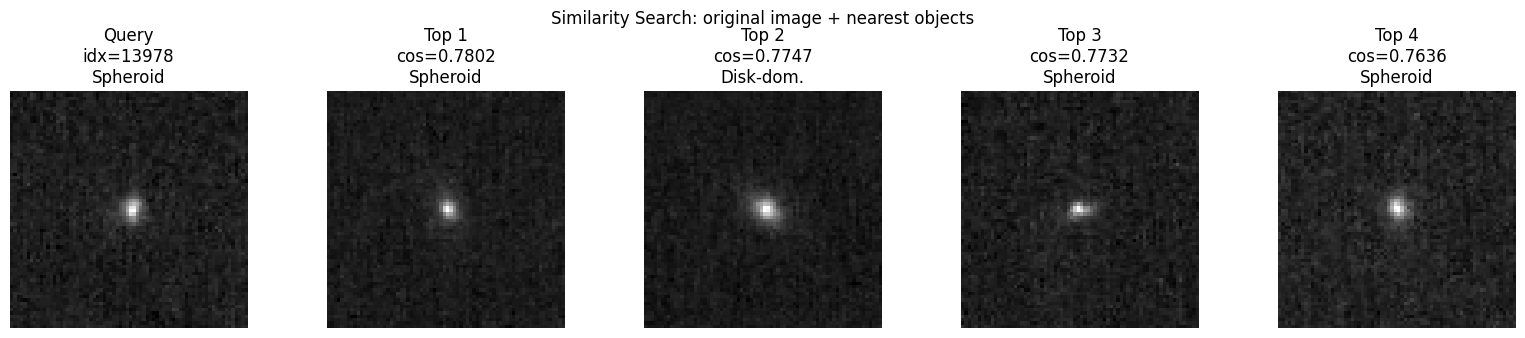

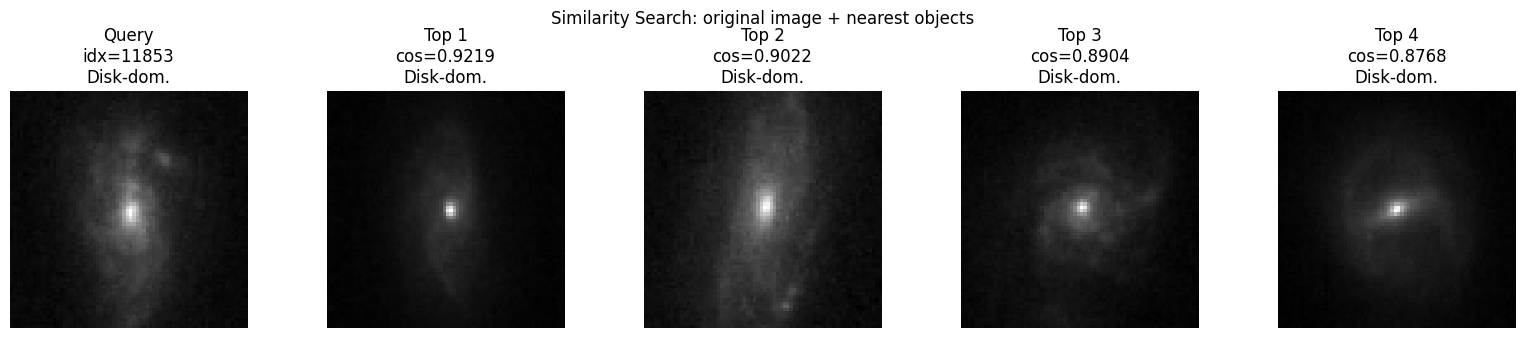

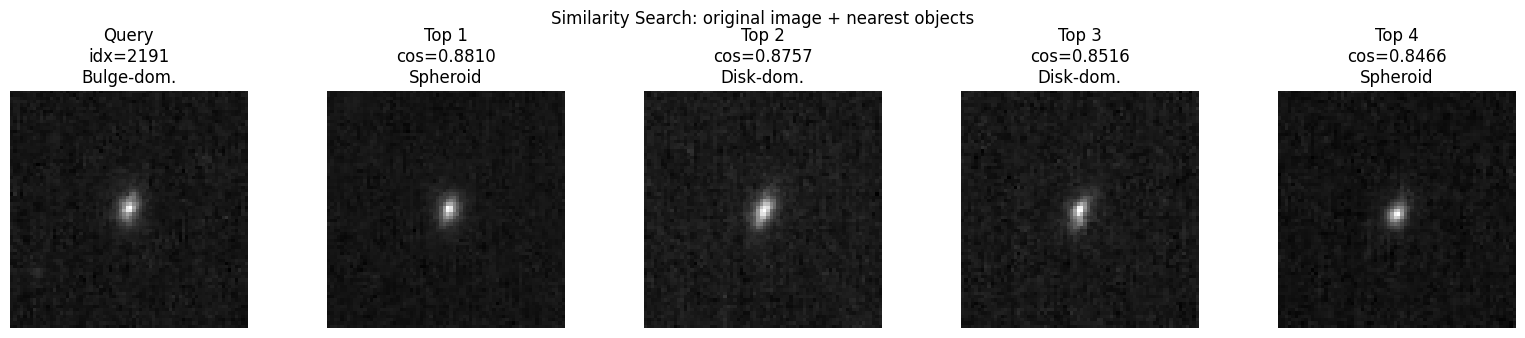

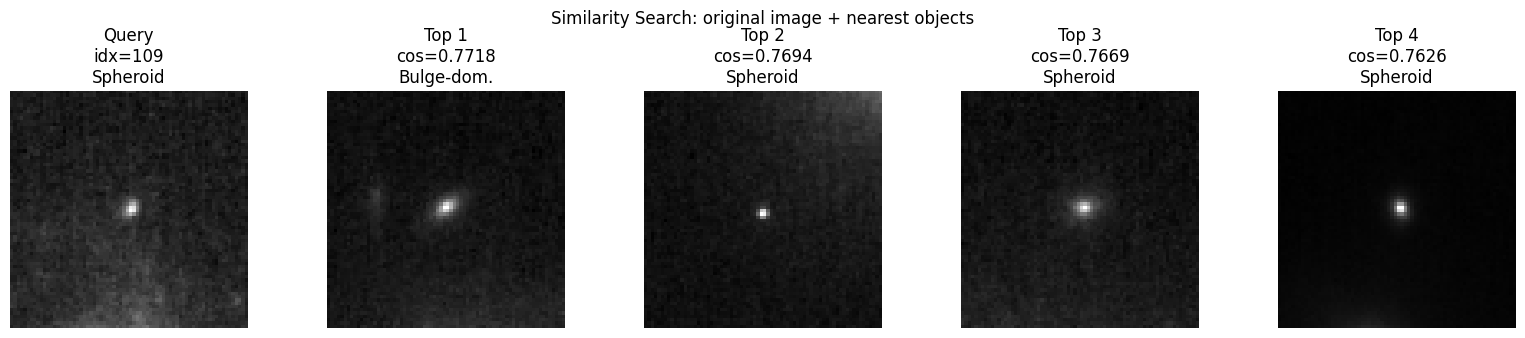

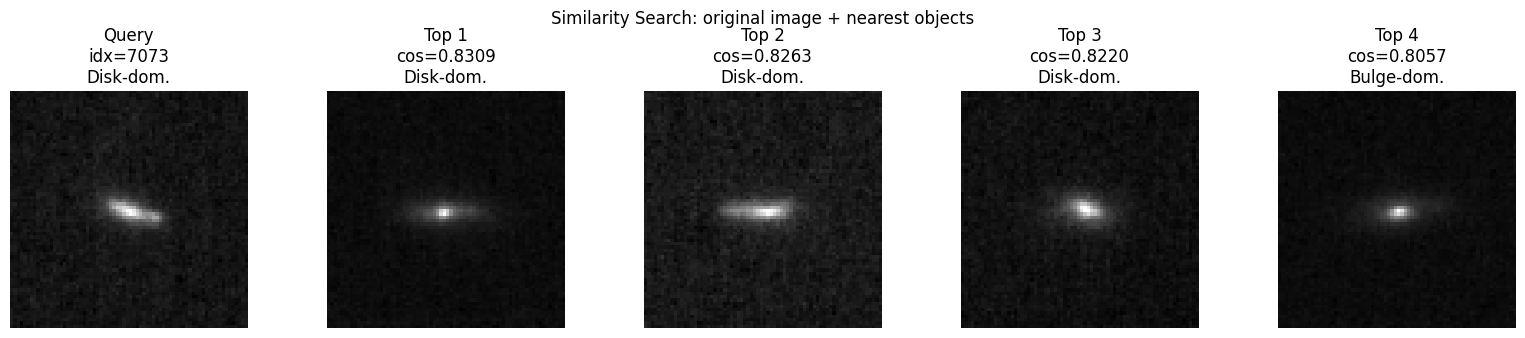

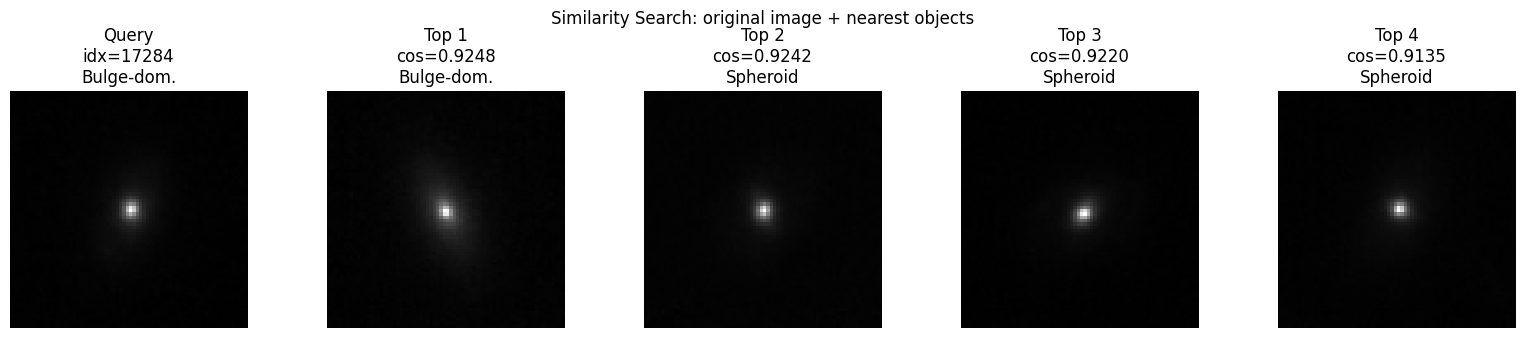

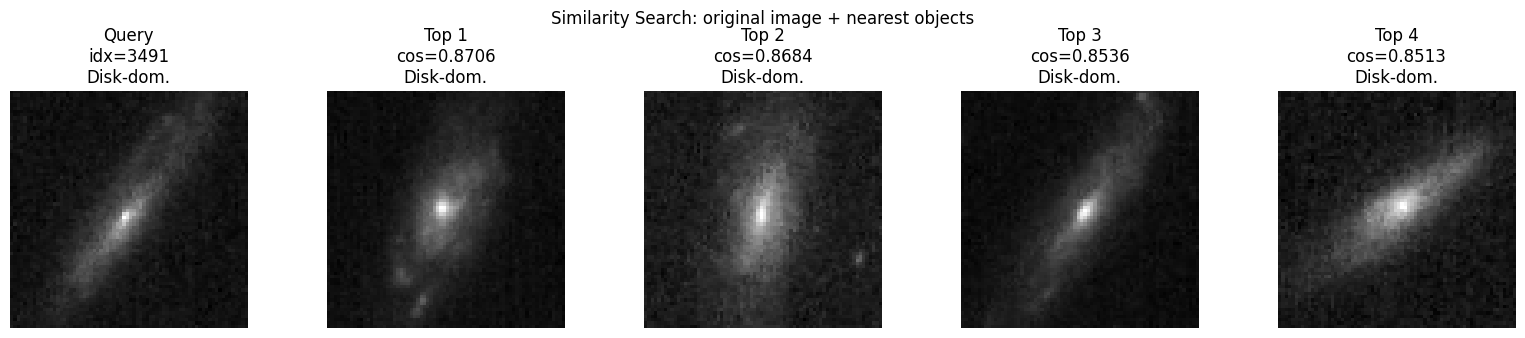

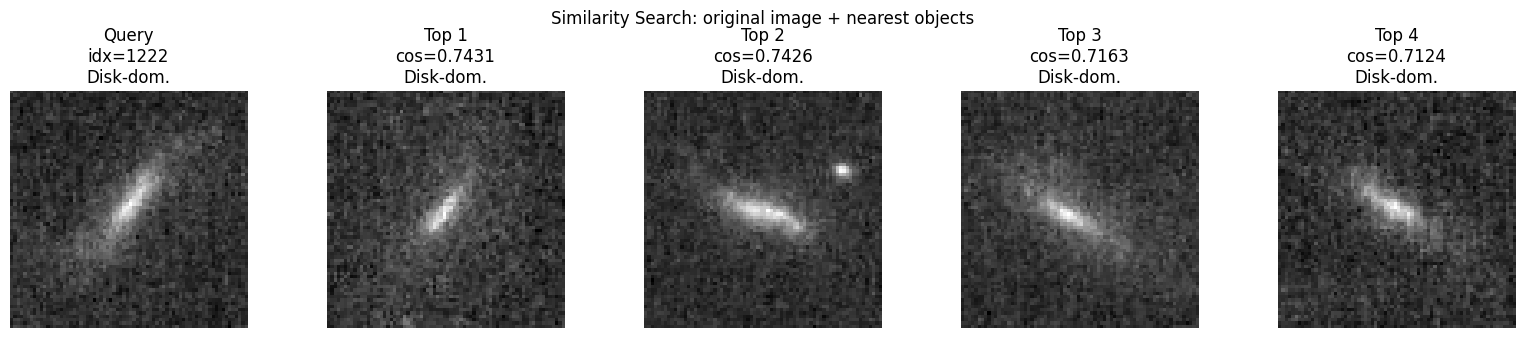

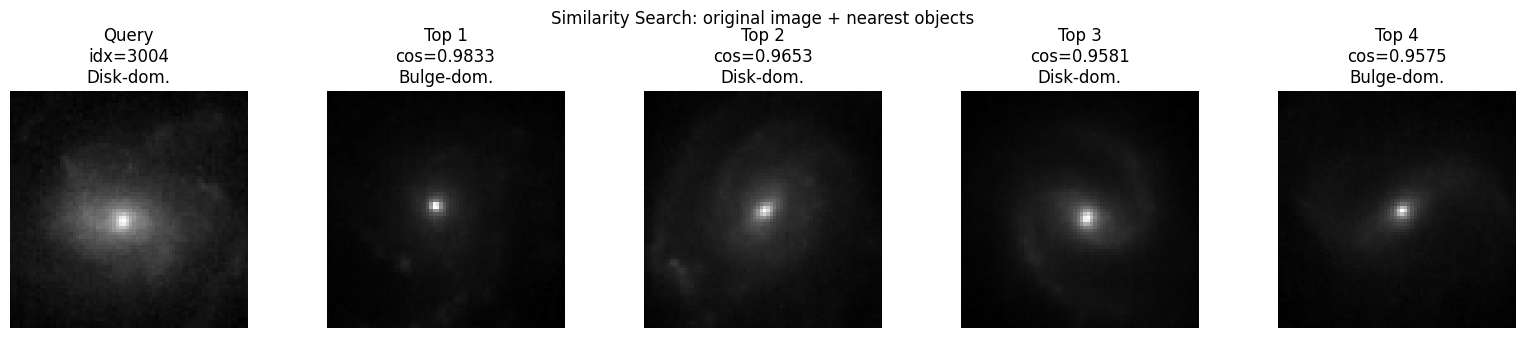

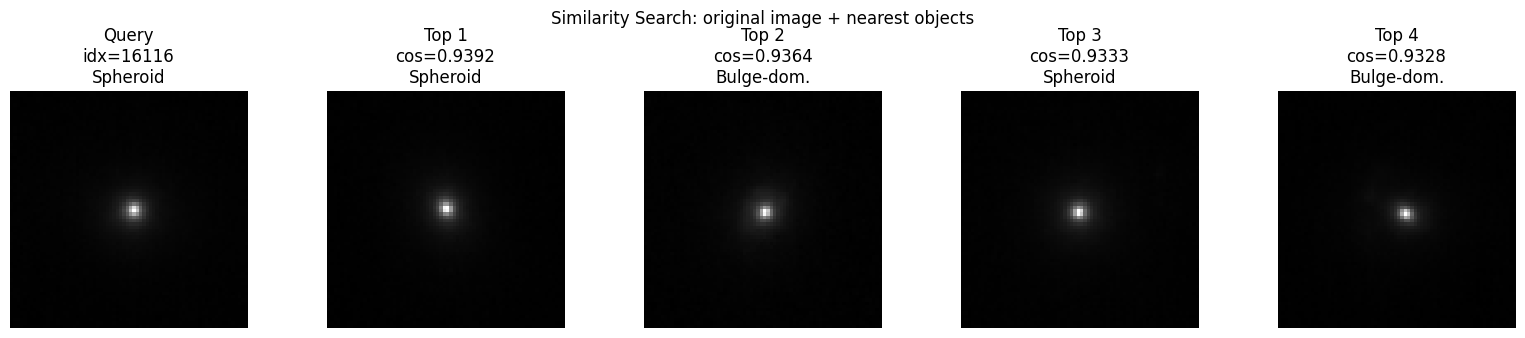

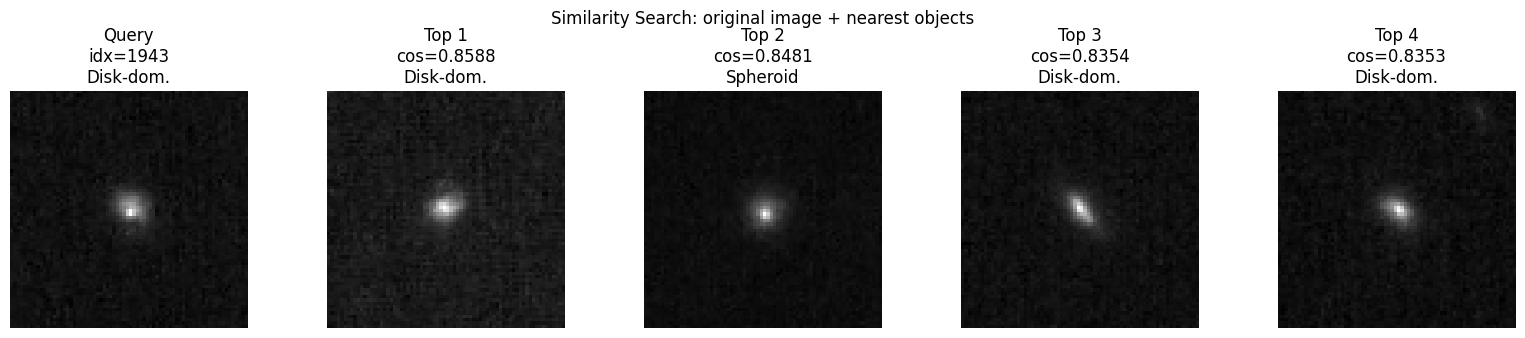

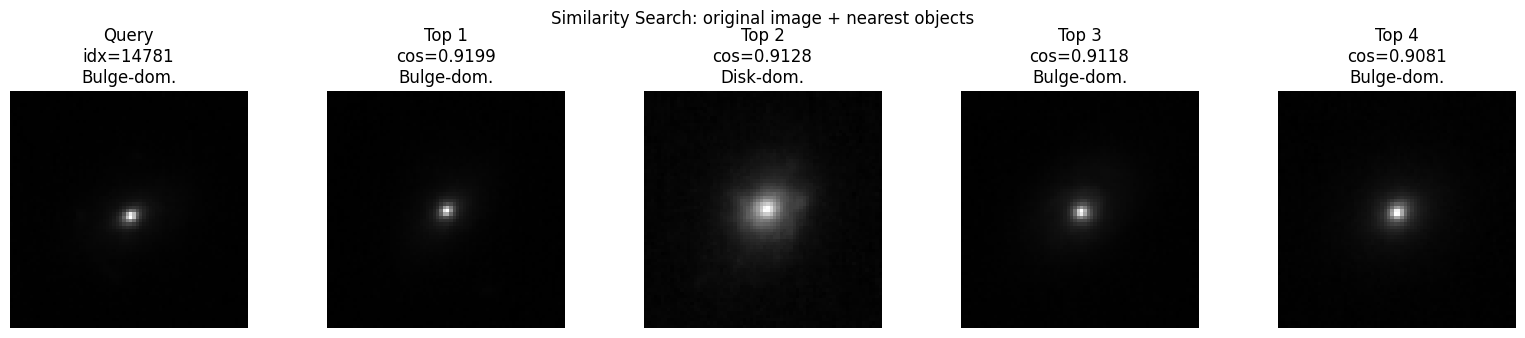

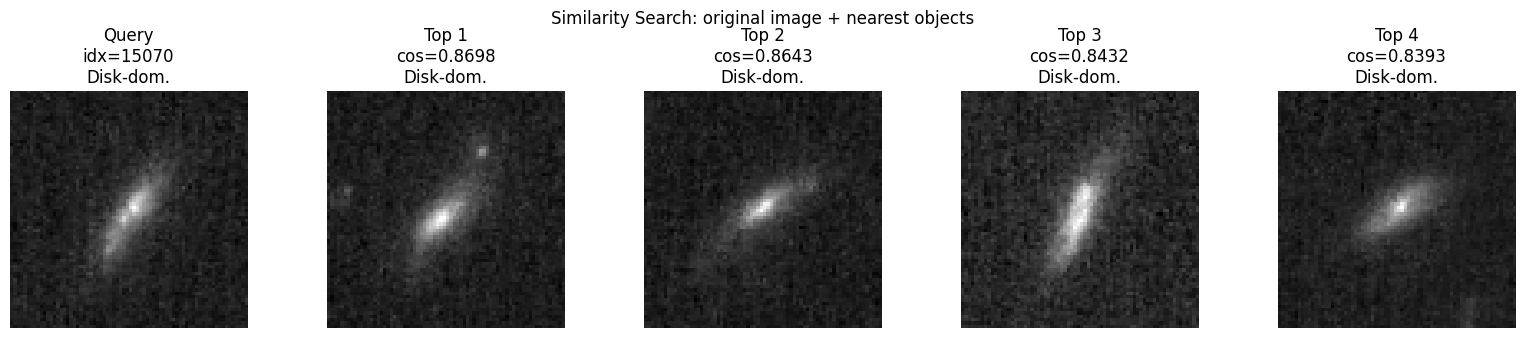

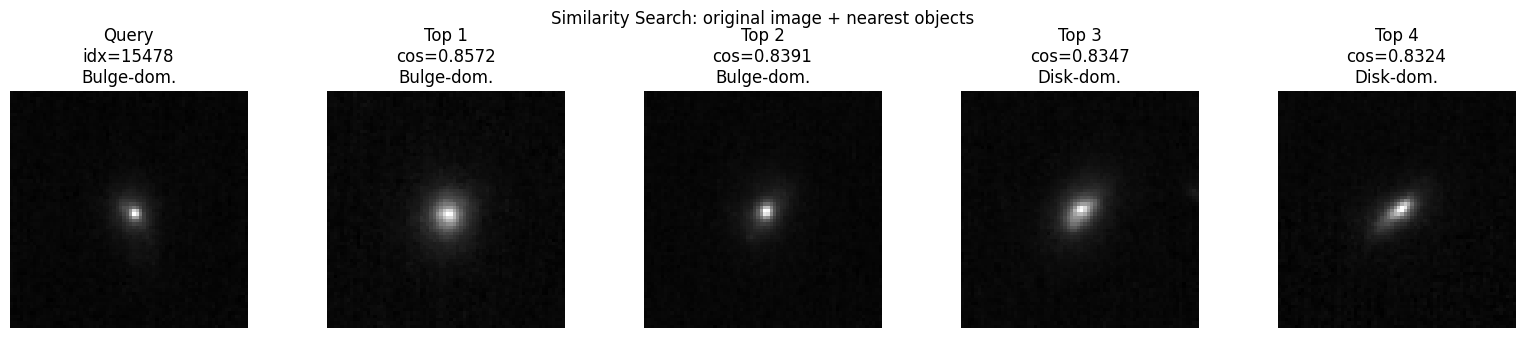

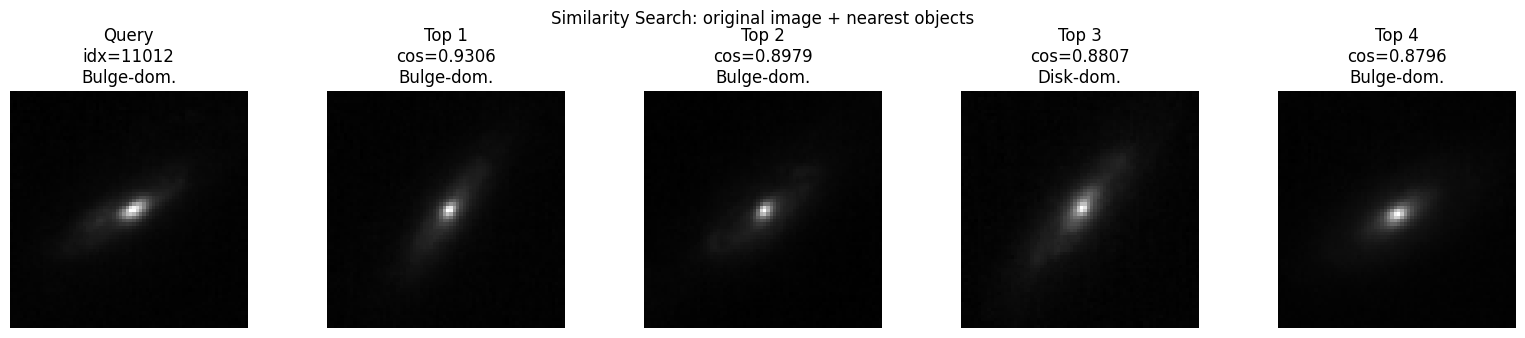

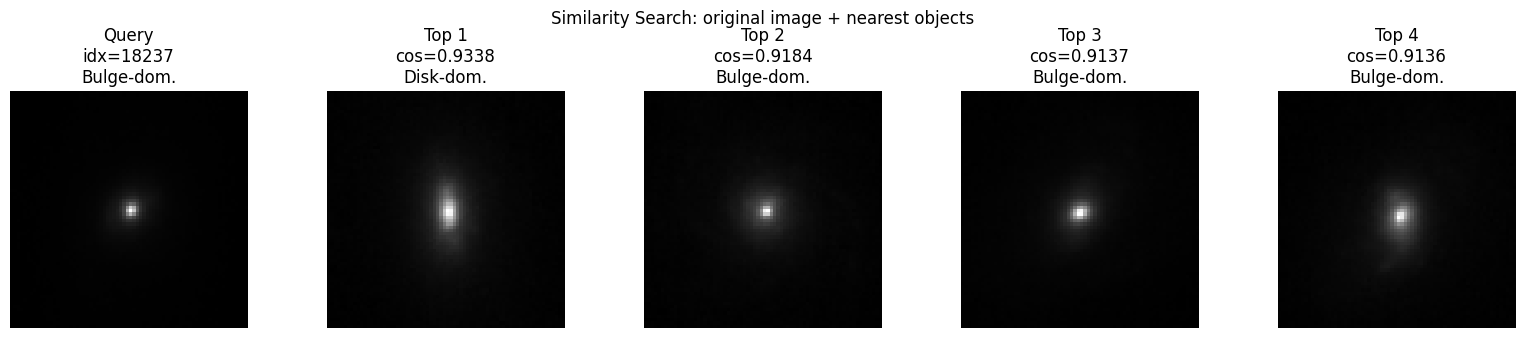

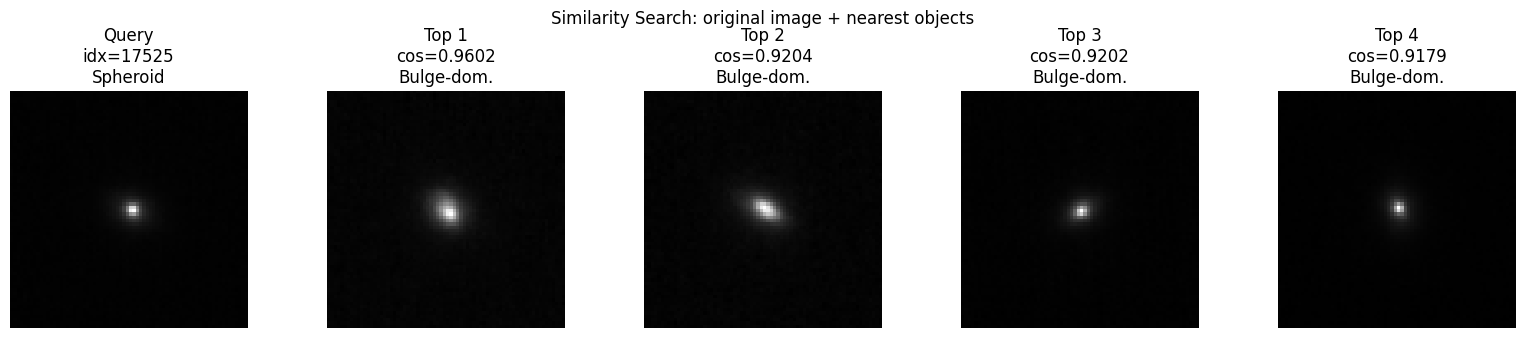

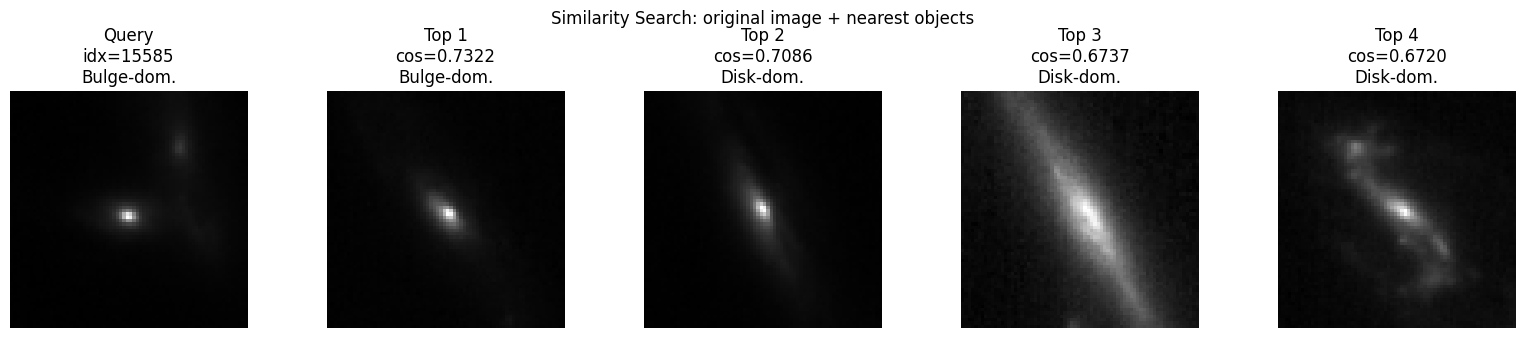

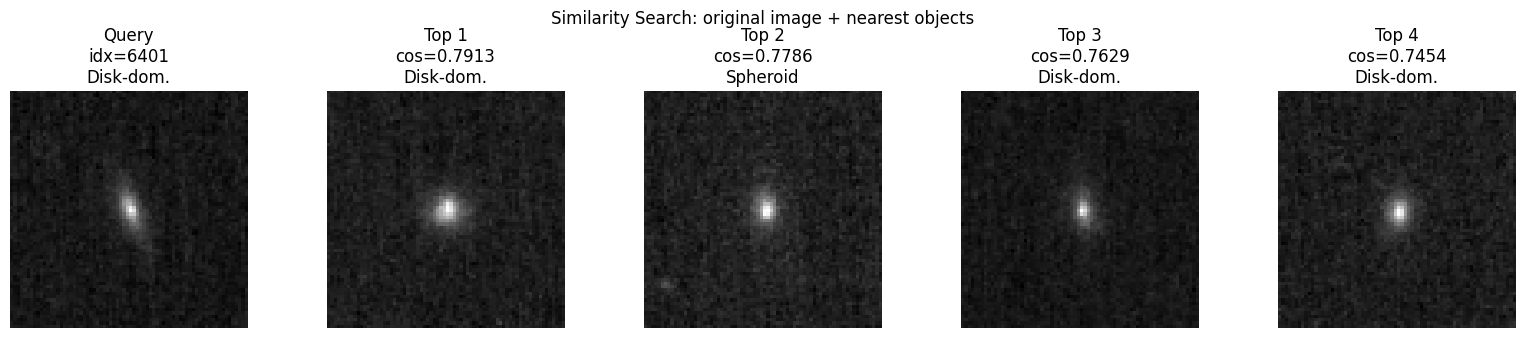

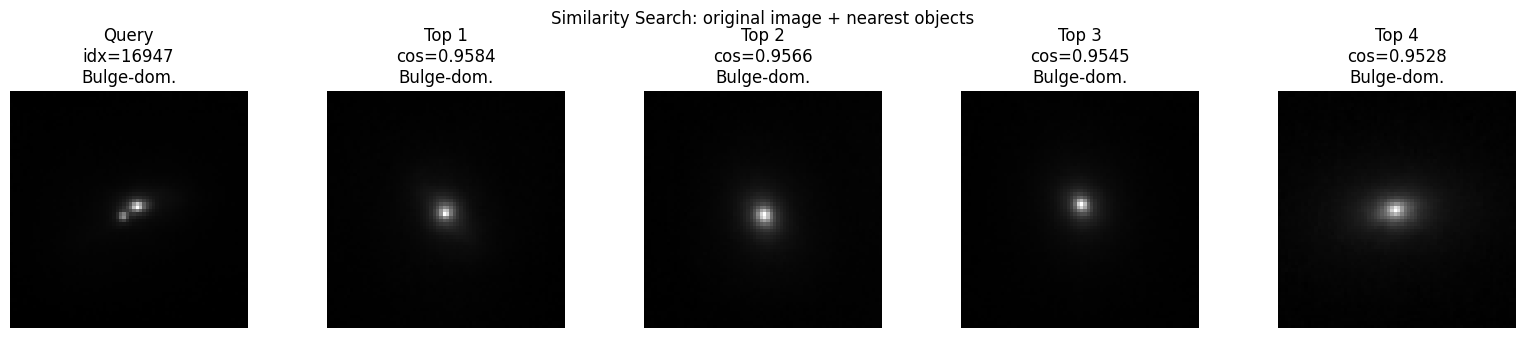

In [14]:
# Quick demo: show many random example plots
TOPK = 4
N_EXAMPLES = 20

_ = plot_many_random_examples(
    ds=ds,
    emb_bank_norm=emb_norm,
    n_examples=N_EXAMPLES,
    topk=TOPK,
    seed=59)



## 5 · Rotation Invariance

Check how stable the model embeddings are under image rotation.

For each sampled galaxy, we rotate the image by a set of angles and compute the **cosine similarity** between the original embedding and each rotated version. A rotation-invariant encoder should maintain high similarity across all angles.

**Method:**
- Sample N images from the dataset
- Rotate each image by angles ∈ {0°, 10°, 20°, …, 350°}
- Encode every (image, rotated image) pair with the frozen model
- Compute `cos_sim(emb_orig, emb_rot)` for each (image, angle)
- Report mean ± std over the sample

In [15]:
import torchvision.transforms.functional as TF

# ── CONFIG ────────────────────────────────────────────────────────────────────
N_ROT_SAMPLES = 200          # number of galaxies to sample
ANGLES        = list(np.linspace(0, 360, 15))   # 0, 10, 20, … 350 degrees
ROT_SEED      = 0
CROP_SIZE     = cfg.crops.global_crops_size
# ─────────────────────────────────────────────────────────────────────────────

rng_rot = np.random.default_rng(ROT_SEED)
sample_idx = rng_rot.choice(len(ds), size=min(N_ROT_SAMPLES, len(ds)), replace=False)

to_rgb_fn = ToRGB()
crop_fn   = transforms.CenterCrop(CROP_SIZE)


def encode_tensor(t3: torch.Tensor) -> torch.Tensor:
    """Encode a (3,H,W) float32 tensor; returns L2-normalised (D,) cpu tensor."""
    inp = t3.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = model(inp)
        if isinstance(emb, tuple):
            emb = emb[0]
        if emb.dim() > 2:
            emb = emb.view(emb.size(0), -1)
        emb = F.normalize(emb.float(), p=2, dim=1)
    return emb.squeeze(0).cpu()


def get_cropped_tensor(ds_idx: int) -> torch.Tensor:
    """Return the cropped, ToRGB-processed (3,H,W) tensor for one dataset item."""
    fi, li, _, _, _ = ds._idx[ds_idx]
    img = ds._files[fi]['image'][li].astype('float32')
    img3 = np.repeat(img[np.newaxis], 3, axis=0)
    t = crop_fn(torch.from_numpy(img3))
    t = torch.from_numpy(to_rgb_fn(t.numpy()))
    return t   # (3, H, W)


def rotate_tensor(t: torch.Tensor, angle: float) -> torch.Tensor:
    """Rotate a (3,H,W) tensor by `angle` degrees (bilinear, reflect padding)."""
    return TF.rotate(t, angle, interpolation=TF.InterpolationMode.BILINEAR)


# ── Compute cosine similarities ───────────────────────────────────────────────
# sim_matrix: (N_ROT_SAMPLES, len(ANGLES))  — angle 0 should be ≈1.0
sim_matrix = np.zeros((len(sample_idx), len(ANGLES)), dtype=np.float32)

for row, ds_idx in enumerate(tqdm(sample_idx, desc='Rotation invariance')):
    t_orig = get_cropped_tensor(int(ds_idx))   # (3,H,W)
    emb_0  = encode_tensor(t_orig)             # L2-norm embedding of unrotated image

    for col, angle in enumerate(ANGLES):
        if angle == 0:
            sim_matrix[row, col] = 1.0
        else:
            t_rot = rotate_tensor(t_orig, angle)
            emb_r = encode_tensor(t_rot)
            sim_matrix[row, col] = float(torch.dot(emb_0, emb_r))

print(f'sim_matrix shape: {sim_matrix.shape}')
print(f'Mean cosine sim (excl. 0°): {sim_matrix[:, 1:].mean():.4f}  '
      f'std: {sim_matrix[:, 1:].std():.4f}')


Rotation invariance: 100%|██████████| 200/200 [00:27<00:00,  7.35it/s]

sim_matrix shape: (200, 15)
Mean cosine sim (excl. 0°): 0.4021  std: 0.2509


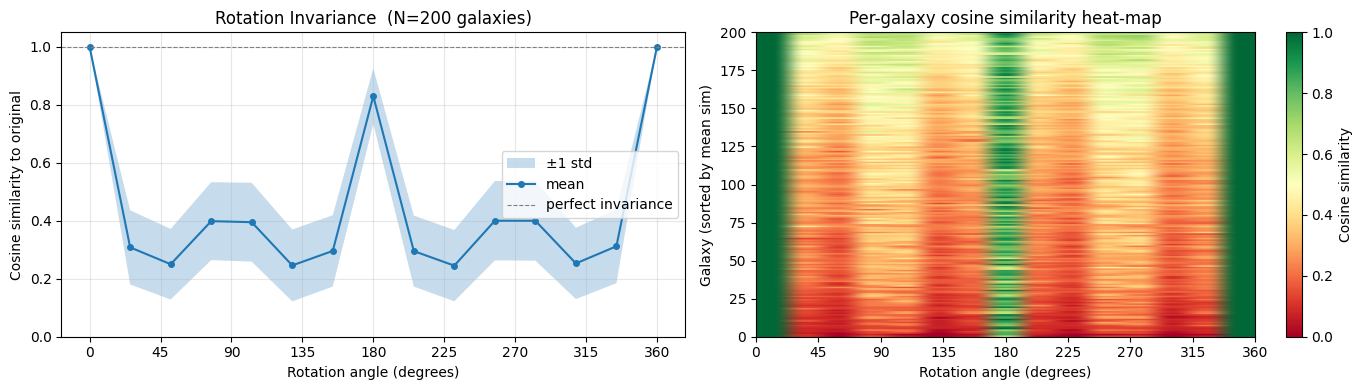

In [16]:
# ── Plot: mean ± std cosine similarity vs rotation angle ─────────────────────
angles_arr = np.array(ANGLES)
mean_sim   = sim_matrix.mean(axis=0)
std_sim    = sim_matrix.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# — Panel 1: mean ± std curve —
ax = axes[0]
ax.fill_between(angles_arr, mean_sim - std_sim, mean_sim + std_sim,
                alpha=0.25, label='±1 std')
ax.plot(angles_arr, mean_sim, 'o-', ms=4, lw=1.5, label='mean')
ax.axhline(1.0, color='gray', lw=0.8, ls='--', label='perfect invariance')
ax.set_xlabel('Rotation angle (degrees)')
ax.set_ylabel('Cosine similarity to original')
ax.set_title(f'Rotation Invariance  (N={len(sample_idx)} galaxies)')
ax.set_xticks(range(0, 361, 45))
ax.set_ylim(max(0, mean_sim.min() - 3 * std_sim.max()), 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

# — Panel 2: per-galaxy heat-map —
ax2 = axes[1]
# Sort galaxies by their mean (excl. 0°) for a cleaner view
order = np.argsort(sim_matrix[:, 1:].mean(axis=1))[::-1]
im = ax2.imshow(
    sim_matrix[order],
    aspect='auto', vmin=0, vmax=1, cmap='RdYlGn',
    extent=[angles_arr[0], angles_arr[-1], 0, len(sample_idx)]
)
plt.colorbar(im, ax=ax2, label='Cosine similarity')
ax2.set_xlabel('Rotation angle (degrees)')
ax2.set_ylabel('Galaxy (sorted by mean sim)')
ax2.set_title('Per-galaxy cosine similarity heat-map')
ax2.set_xticks(range(0, 361, 45))

plt.tight_layout()
plt.show()
